In [1]:
import os

# setting the Kaggle API Token environment variable directly in Colab memory
os.environ["KAGGLE_API_TOKEN"] = "YOUR_KAGGLE_API_KEY"
print("Kaggle Token successfully authenticated!")

Kaggle Token successfully authenticated!


In [2]:
!pip install fiftyone tensorflow tensorflow-hub opencv-python-headless kaggle pycocotools matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 8.0 MB/s eta 0:0

In [3]:
# Necessary libraries
import fiftyone as fo
import fiftyone.zoo as foz
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


In [4]:
#data collection
TARGET_CLASSES = ["Person", "Car" ]

for ds_name in ["clean_train_data", "clean_test_data"]:
    if ds_name in fo.list_datasets():
        fo.delete_dataset(ds_name)

print("Downloading balanced data across 2 target classes simultaneously...")

# Pull exactly 300 training samples per class in ONE action
train_dataset = foz.load_zoo_dataset(
    "open-images-v6",
    split="train",
    label_types=["detections"],
    classes=TARGET_CLASSES,
    max_samples=600,
    seed=42,
    shuffle=True,
    only_matching=True
)
train_dataset.name = "clean_train_data"
train_dataset.persistent = True

# Pull exactly 100 validation samples per class in ONE action
test_dataset = foz.load_zoo_dataset(
    "open-images-v6",
    split="validation",
    label_types=["detections"],
    classes=TARGET_CLASSES,
    max_samples=200,
    seed=42,
    shuffle=True,
    only_matching=True
)
test_dataset.name = "clean_test_data"
test_dataset.persistent = True

print(f"\nDataset extraction complete!")
print(f"Verified Train Size: {len(train_dataset)} images")
print(f"Verified Test Size: {len(test_dataset)} images")

INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v6/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v6/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [5.7s elapsed, 0s remaining, 998.1Mb/s]      


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [5.7s elapsed, 0s remaining, 998.1Mb/s]      


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v6/train/metadata/classes.csv'


...

 100% |█████████████████| 200/200 [1.5s elapsed, 0s remaining, 137.0 samples/s]         


INFO:eta.core.utils: 100% |█████████████████| 200/200 [1.5s elapsed, 0s remaining, 137.0 samples/s]         


Dataset 'open-images-v6-validation-200' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v6-validation-200' created



Dataset extraction complete!
Verified Train Size: 600 images
Verified Test Size: 200 images


In [5]:
#Preprocessing the data
NUM_CLASSES = 2
BATCH_SIZE = 4
EPOCHS = 25

print("Building highly optimized parallel tf.data pipelines...")

def prepare_sample(filepath, bboxes, c_ids):
    #Handles image loading, decoding, and normalization on-the-fly.
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (320, 320))
    img = tf.cast(img, tf.float32) / 255.0  # Normalize pixel space

    return img, {"boxes": bboxes, "classes": c_ids}

def build_pipeline(dataset_split):
    file_paths = []
    all_boxes = []
    all_classes = []

    # Generates exact zero-indexed mapping: {"Person": 0, "Car": 1}
    class_to_id = {cls_name: idx for idx, cls_name in enumerate(TARGET_CLASSES)}

    for sample in dataset_split:
        if not hasattr(sample, "ground_truth") or sample.ground_truth is None:
            continue

        bboxes = []
        c_ids = []

        for det in sample.ground_truth.detections:
            if det.label in class_to_id:
                xmin, ymin, w, h = det.bounding_box
                # Map FiftyOne bounding format to TensorFlow normalized format
                bboxes.append([ymin, xmin, ymin + h, xmin + w])
                c_ids.append(class_to_id[det.label])

        if len(bboxes) == 0:
            continue

        # Pad up to 10 instances using -1 to explicitly flag background slots
        while len(bboxes) < 10:
            bboxes.append([0.0, 0.0, 0.0, 0.0])
            c_ids.append(-1)

        # Append data slices to memory trackers
        file_paths.append(sample.filepath)
        all_boxes.append(bboxes[:10])
        all_classes.append(c_ids[:10])

    # Convert to explicit signed integer formats to support negative padding indices safely
    dataset = tf.data.Dataset.from_tensor_slices((
        file_paths,
        np.array(all_boxes, dtype=np.float32),
        np.array(all_classes, dtype=np.int32)  # Signed int handles -1 cleanly
    ))

    # Parallel mapping over CPU threads
    dataset = dataset.map(
        lambda fp, b, c: prepare_sample(fp, b, c),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return dataset

# Compile parallel hardware streaming pipelines
tf_train_data = build_pipeline(train_dataset).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
tf_test_data = build_pipeline(test_dataset).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Scalable parallel pipelines compiled successfully for 2 classes!")

Building highly optimized parallel tf.data pipelines...
Scalable parallel pipelines compiled successfully for 2 classes!


In [6]:
# Model training
import tensorflow as tf

inputs = tf.keras.Input(shape=(320, 320, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(320, 320, 3), input_tensor=x, include_top=False, weights='imagenet'
)

# Unfreeze the backbone so it can learn custom object shapes
base_model.trainable = True

# Refreeze only the bottom layers to protect foundational features (edges, textures)
for layer in base_model.layers[:-40]:
    layer.trainable = False

features = base_model.output

# SSD Local Spatial Detectors
conv_loc = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')(features)
conv_loc = tf.keras.layers.BatchNormalization()(conv_loc)

pool_spatial = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)(conv_loc)
up_to_anchors = tf.keras.layers.UpSampling2D(size=(10, 1))(pool_spatial)

# Bounding Box Anchor Head
box_conv = tf.keras.layers.Conv2D(4, (1, 1), padding='same')(up_to_anchors)
box_output_layer = tf.keras.layers.Reshape((10, 4))(box_conv)
box_output = tf.keras.layers.Activation('sigmoid', name="boxes")(box_output_layer)

# Classification Head
class_conv = tf.keras.layers.Conv2D(NUM_CLASSES, (1, 1), padding='same')(up_to_anchors)
class_output_layer = tf.keras.layers.Reshape((10, NUM_CLASSES))(class_conv)
class_output = tf.keras.layers.Activation('softmax', name="classes")(class_output_layer)

# Instantiate the final Functional Model
model = tf.keras.Model(inputs=inputs, outputs={"boxes": box_output, "classes": class_output})

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
    loss={
        "boxes": tf.keras.losses.Huber(),
        "classes": tf.keras.losses.SparseCategoricalCrossentropy(ignore_class=-1)
    },
    loss_weights={"boxes": 40.0, "classes": 1.0}
)

print("Fine-Tuning SSD Model Compiled Successfully with Pure Keras Layers!")

history = model.fit(
    tf_train_data,
    validation_data=tf_test_data,
    epochs=EPOCHS
)


/tmp/ipykernel_915/1150853469.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fine-Tuning SSD Model Compiled Successfully with Pure Keras Layers!
Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 135s 784ms/step - boxes_loss: 0.0718 - classes_loss: 0.6941 - loss: 3.5660 - val_boxes_loss: 0.1002 - val_classes_loss: 0.7306 - val_loss: 4.7376
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 115s 767ms/step - boxes_loss: 0.0648 - classes_loss: 0.6148 - loss: 3.2064 - val_boxes_loss: 0.0963 - val_classes_loss: 0.7078 - val_loss: 4.5617
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 145s 790ms/step - boxes_loss: 0.0614 - classes_loss: 0.5744 - loss: 3.0286 - val_boxes_loss: 0.0925 - val_classes_loss: 0.7112 - val_loss: 4.4122
Epoch 4/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 120s 799ms/step - boxes_loss: 0.0592 - classes_loss: 0.5511 - loss: 2.9209 - val_boxes_loss: 0.0874 - val_classes_loss: 0.7159 - val_loss: 4.2130
Epoch 5/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 139s 782ms/step - boxes_loss: 0.0581 - classes_loss: 0.5390 - loss: 2.8621 - val_boxes_loss: 0.0947


Generating Convergence Curves from SSD Training History...


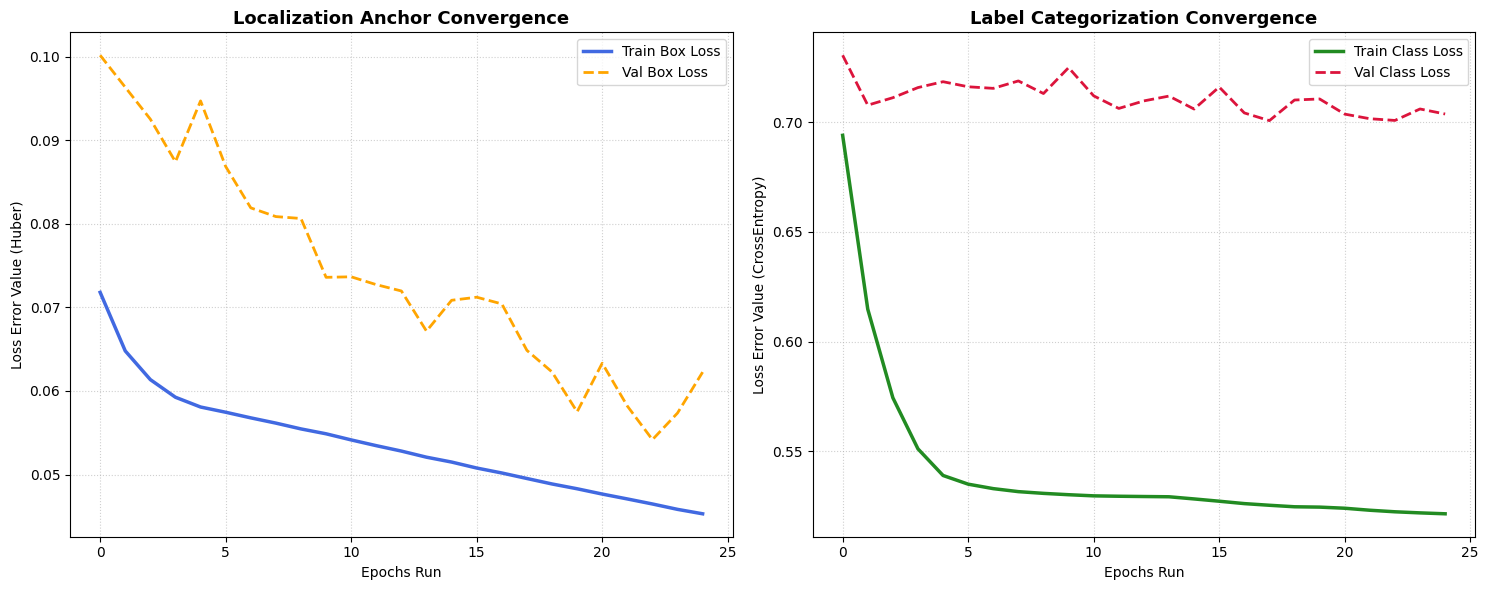

In [7]:
#model testing
import matplotlib.pyplot as plt

print("\nGenerating Convergence Curves from SSD Training History...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Box Loss Plot
ax1.plot(history.history.get('boxes_loss', history.history.get('loss', [])),
         label='Train Box Loss', color='royalblue', linewidth=2.5)
if 'val_boxes_loss' in history.history:
    ax1.plot(history.history['val_boxes_loss'], label='Val Box Loss', color='orange', linestyle='--', linewidth=2)
ax1.set_title('Localization Anchor Convergence', fontsize=13, weight='bold')
ax1.set_xlabel('Epochs Run'); ax1.set_ylabel('Loss Error Value (Huber)')
ax1.legend(loc='upper right'); ax1.grid(True, linestyle=':', alpha=0.6)

# Class Loss Plot
if 'classes_loss' in history.history:
    ax2.plot(history.history['classes_loss'], label='Train Class Loss', color='forestgreen', linewidth=2.5)
    if 'val_classes_loss' in history.history:
        ax2.plot(history.history['val_classes_loss'], label='Val Class Loss', color='crimson', linestyle='--', linewidth=2)
else:
    ax2.plot(history.history['loss'], label='Total Compound Loss', color='purple', linewidth=2.5)
ax2.set_title('Label Categorization Convergence', fontsize=13, weight='bold')
ax2.set_xlabel('Epochs Run'); ax2.set_ylabel('Loss Error Value (CrossEntropy)')
ax2.legend(loc='upper right'); ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()




Calculating model performance metrics on test dataset...

=== DETAILED PERFORMANCE METRICS ===
              precision    recall  f1-score   support

      Person       0.62      0.71      0.66       597
         Car       0.49      0.39      0.44       426

    accuracy                           0.58      1023
   macro avg       0.56      0.55      0.55      1023
weighted avg       0.57      0.58      0.57      1023


Generating Confusion Matrix Heatmap...


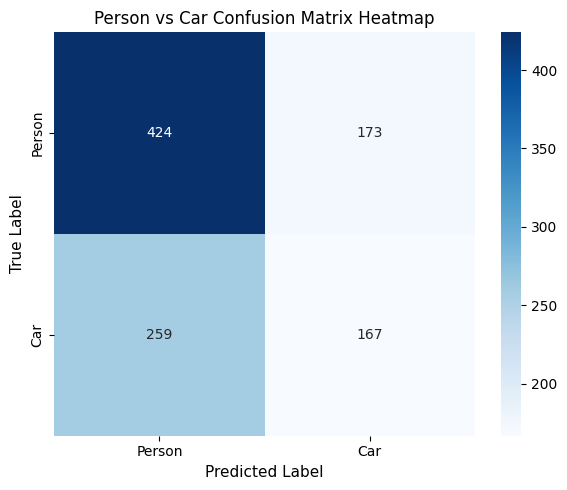

In [8]:
#model testing
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\nCalculating model performance metrics on test dataset...")

all_true_classes = []
all_pred_classes = []

# Loop through the test data batches
for images, targets in tf_test_data:
    true_boxes = targets["boxes"].numpy()
    true_classes = targets["classes"].numpy()

    # Run model inference
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds["classes"], axis=-1)

    # Flatten the batches to look at individual object slots
    for b in range(images.shape[0]):
        for o in range(10): # 10 maximum slots per image
            t_cls = true_classes[b, o]
            p_cls = pred_classes[b, o]
            if t_cls == -1:
                continue

            all_true_classes.append(t_cls)
            all_pred_classes.append(p_cls)

# Convert compiled lists to numpy arrays
y_true = np.array(all_true_classes)
y_pred = np.array(all_pred_classes)


print("\n=== DETAILED PERFORMANCE METRICS ===")
# Explicitly mapping to your 2 active indices (0: Person, 1: Car)
all_indices = [0, 1]
class_names = TARGET_CLASSES  # ["Person", "Car"]

report = classification_report(
    y_true,
    y_pred,
    labels=all_indices,       # Force metrics tracking for exactly your 2 classes
    target_names=class_names,
    zero_division=0
)
print(report)


print("\nGenerating Confusion Matrix Heatmap...")
# Calculate matrix strictly across your 2 active indices
cm = confusion_matrix(y_true, y_pred, labels=all_indices)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Person vs Car Confusion Matrix Heatmap', fontsize=12)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()


Generating Clean SSD Visual Inference Examples with NMS Filtering...


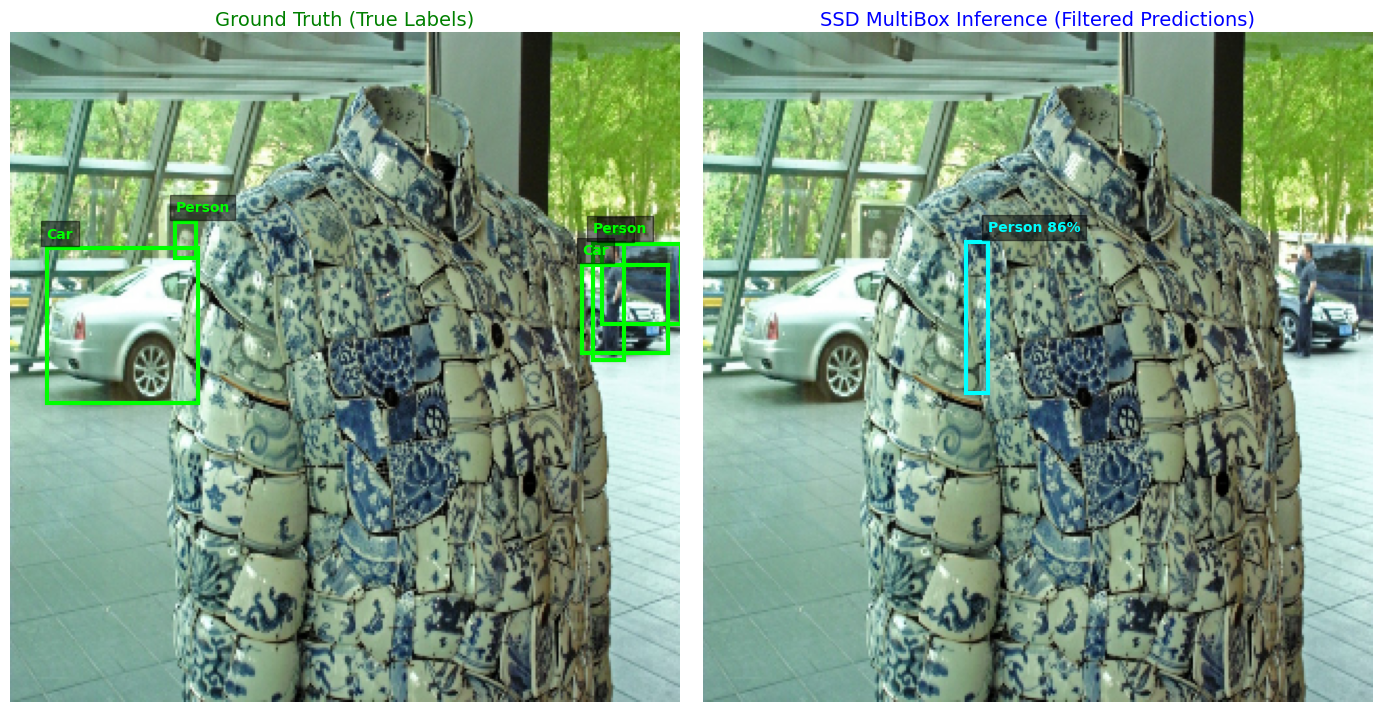

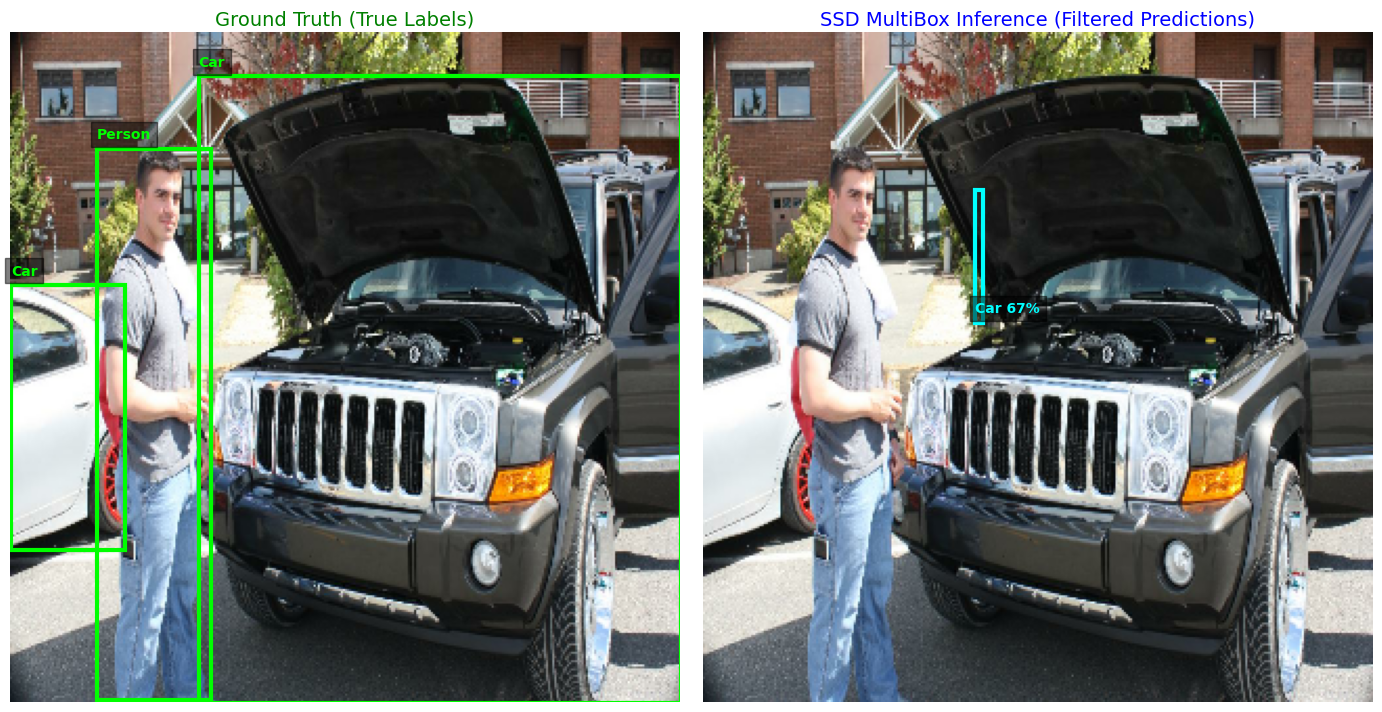

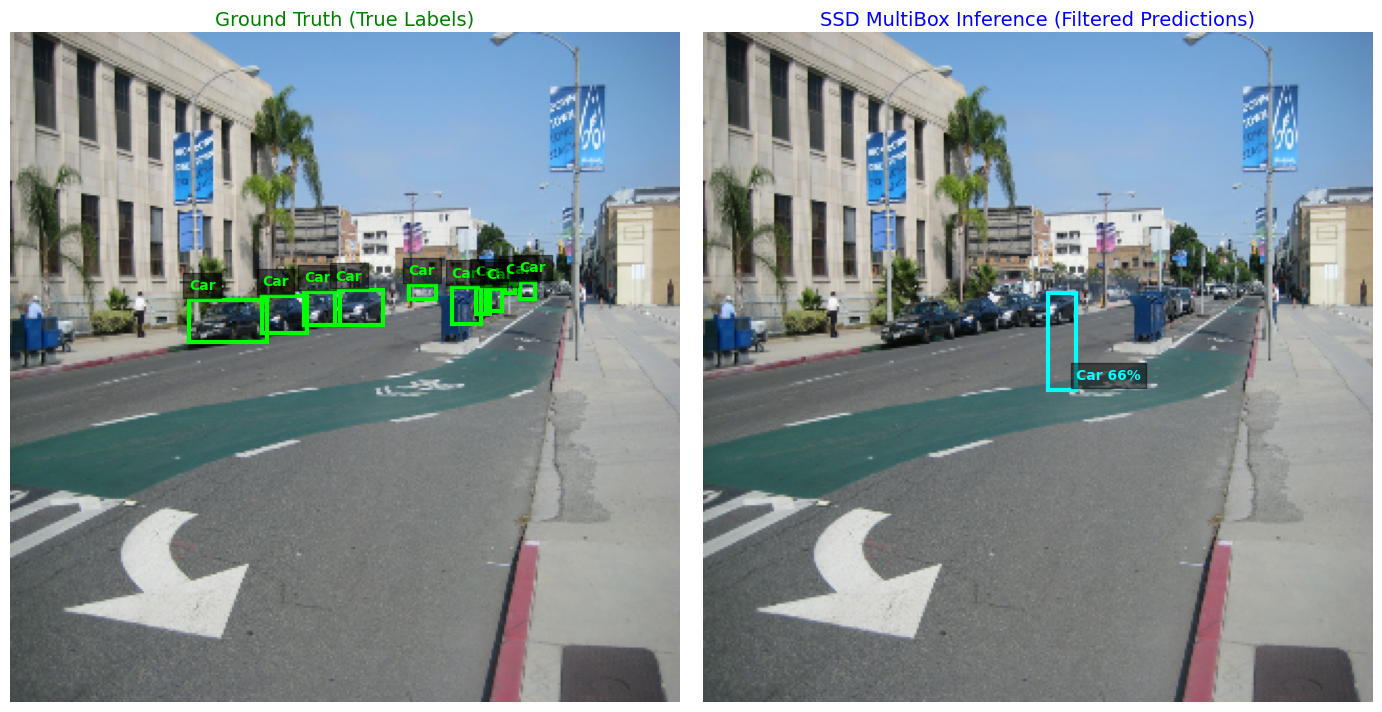

In [9]:
# Results
print("\nGenerating Clean SSD Visual Inference Examples with NMS Filtering...")

id_to_class = {idx: cls_name for idx, cls_name in enumerate(TARGET_CLASSES)}
id_to_class[-1] = "Background"

for images, targets in tf_test_data.take(1):
    preds = model.predict(images, verbose=0)

    pred_boxes = preds["boxes"]
    pred_classes_scores = preds["classes"]

    true_boxes = targets["boxes"].numpy()
    true_classes = targets["classes"].numpy()

    num_to_display = min(images.shape[0], 3)
    for idx in range(num_to_display):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
        img_display = images[idx].numpy()

        ax1.imshow(img_display)
        ax1.set_title("Ground Truth (True Labels)", fontsize=14, color='green')
        ax1.axis('off')

        for o in range(10):
            t_cls = true_classes[idx, o]
            if t_cls != -1:
                ymin, xmin, ymax, xmax = true_boxes[idx, o] * 320
                rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color='lime', linewidth=3)
                ax1.add_patch(rect)
                ax1.text(xmin, ymin - 5, id_to_class.get(t_cls, "Unknown"), color='lime', weight='bold', bbox=dict(facecolor='black', alpha=0.5))

        ax2.imshow(img_display)
        ax2.set_title("SSD MultiBox Inference (Filtered Predictions)", fontsize=14, color='blue')
        ax2.axis('off')

        # Extract predictions for this specific image from the arrays
        boxes = pred_boxes[idx]
        classes = np.argmax(pred_classes_scores[idx], axis=-1)
        scores = np.max(pred_classes_scores[idx], axis=-1)

        # Non-Maximum Suppression (Deletes chaotic overlapping duplicate boxes)
        # Filters out all background noise under 55% confidence threshold cleanly
        selected_indices = tf.image.non_max_suppressing = tf.image.non_max_suppression(
            boxes, scores, max_output_size=5, iou_threshold=0.3, score_threshold=0.55
        ).numpy()

        for o in selected_indices:
            p_cls = classes[o]
            # Draw prediction box if it is a real target class (0: Person, 1: Car)
            if p_cls in [0, 1]:
                ymin, xmin, ymax, xmax = boxes[o] * 320
                rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color='cyan', linewidth=3)
                ax2.add_patch(rect)

                label_text = f"{id_to_class.get(p_cls, 'Unknown')} {scores[o]*100:.0f}%"
                ax2.text(xmin, ymin - 5, label_text, color='cyan', weight='bold', bbox=dict(facecolor='black', alpha=0.5))

        plt.tight_layout()
        plt.show()